# EPG Spatial Transfer Diagnostics

This notebook diagnoses why the spatial random-forest workflow is weak for `EPG heating` and `EPG cooling`. It reads the latest saved training outputs and does not retrain the random forests.

The diagnosis focuses on four questions:

1. Does the trained model beat simple train-mean baselines under the same fixed-test and spatial-CV roles?
2. Are EPG target distributions and prediction biases shifted by NUTS3 region?
3. Where are large residuals located geographically?
4. Which allowed predictors are important or remain correlated with residual errors?


In [1]:
from __future__ import annotations

import json
import sys
from importlib import import_module, reload
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm
from sklearn.metrics import mean_absolute_error, r2_score

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
try:
    from IPython.display import display
except Exception:
    display = print

EPG_TARGETS = ["EPG heating", "EPG cooling"]

In [2]:
REPO_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "pipeline" / "config").exists()
)
sys.path.append(str(REPO_ROOT))

from pipeline.utils.paths import load_paths, path_value, repo_data_path

rf_utils = reload(import_module("pipeline.3_epvi_prediction.utils"))
PATHS = load_paths()
MODEL_OUT_DIR = path_value(PATHS, "external_data_root") / "outputs" / "epvi_prediction" / "random_forest"
PARISH_GEOMETRY_GEOJSON = repo_data_path(PATHS, "parishes.geojson")

# Must match the scope used in model_training.ipynb for the outputs being inspected.
EXCLUDE_OVERSEAS_TERRITORIES = True
OVERSEAS_NUTS3 = tuple(rf_utils.OVERSEAS_NUTS3)
MODEL_SCOPE_LABEL = "mainland_only" if EXCLUDE_OVERSEAS_TERRITORIES else "all_territories"

metrics_path = rf_utils.latest_file(MODEL_OUT_DIR, "rf_epvi_metrics_*.csv")
if metrics_path is None:
    raise FileNotFoundError(f"No RF metrics found in {MODEL_OUT_DIR}. Run model_training.ipynb first.")
stamp = metrics_path.stem.removeprefix("rf_epvi_metrics_")
predictions_path = MODEL_OUT_DIR / f"rf_epvi_predictions_residuals_{stamp}.csv"
importances_path = MODEL_OUT_DIR / f"rf_epvi_feature_importances_{stamp}.csv"
params_path = MODEL_OUT_DIR / f"rf_epvi_best_params_{stamp}.json"
folds_path = MODEL_OUT_DIR / f"rf_epvi_spatial_cv_folds_{stamp}.csv"
required = [metrics_path, predictions_path, importances_path, params_path, folds_path]
missing = [path for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(f"Latest RF output stamp {stamp} is incomplete: {missing}")

print("output stamp:", stamp)
print("expected model scope:", MODEL_SCOPE_LABEL)
for path in required:
    print(" -", path)

output stamp: mainland_only_20260527_200201
expected model scope: mainland_only
 - E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_metrics_mainland_only_20260527_200201.csv
 - E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_predictions_residuals_mainland_only_20260527_200201.csv
 - E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_feature_importances_mainland_only_20260527_200201.csv
 - E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_best_params_mainland_only_20260527_200201.json
 - E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_spatial_cv_folds_mainland_only_20260527_200201.csv


In [3]:
metrics = pd.read_csv(metrics_path)
predictions = pd.read_csv(predictions_path)
importances = pd.read_csv(importances_path)
folds = pd.read_csv(folds_path)
with open(params_path, "r", encoding="utf-8") as f:
    best_params = json.load(f)

epg_metrics = metrics[metrics["target"].isin(EPG_TARGETS)].copy()
epg_predictions = predictions[predictions["target"].isin(EPG_TARGETS)].copy()
epg_importances = importances[importances["target"].isin(EPG_TARGETS)].copy()
epg_folds = folds[folds["target"].eq(EPG_TARGETS[0])].copy()

has_overseas_predictions = predictions["NUTS3"].isin(OVERSEAS_NUTS3).any()
if EXCLUDE_OVERSEAS_TERRITORIES and has_overseas_predictions:
    raise ValueError(
        "The latest model outputs include PT200/PT300, but EXCLUDE_OVERSEAS_TERRITORIES=True. "
        "Rerun model_training.ipynb with the same scope switch before using this notebook."
    )
if not EXCLUDE_OVERSEAS_TERRITORIES and not has_overseas_predictions:
    print("WARNING: latest outputs do not contain overseas territories; they look like a mainland-only run.")

display(epg_metrics[[
    "target", "n_train_rows", "n_test_rows", "search_spatial_cv_r2_mean",
    "train_spatial_cv_r2", "fixed_test_r2", "fixed_test_rmse", "fixed_test_spearman",
]])
display(pd.DataFrame(best_params).T.loc[EPG_TARGETS])
display(epg_folds)

,target,n_train_rows,n_test_rows,search_spatial_cv_r2_mean,train_spatial_cv_r2,fixed_test_r2,fixed_test_rmse,fixed_test_spearman
2,EPG cooling,2309,573,-0.026069,0.261566,0.414134,0.773015,0.608541
4,EPG heating,2309,573,0.175619,0.290034,0.033316,1.385323,0.192240


,model__n_estimators,model__min_samples_split,model__min_samples_leaf,model__max_features,model__max_depth
EPG heating,800,5,12,sqrt,24
EPG cooling,500.0,2.0,1.0,0.35,32.0


,model_scope,target,fold,n_rows,n_nuts3,validation_nuts3
0,mainland_only,EPG heating,0,494,3,"PT111, PT11D, PT186"
1,mainland_only,EPG heating,1,463,3,"PT119, PT11C, PT170"
2,mainland_only,EPG heating,2,461,3,"PT11A, PT11E, PT16I"
3,mainland_only,EPG heating,3,449,4,"PT11B, PT16B, PT16D, PT16E"
4,mainland_only,EPG heating,4,442,6,"PT150, PT16F, PT16G, PT16H, PT181, PT184"


## Baseline Check

A weak random forest can still be useful if it beats a baseline. The fixed-test baseline predicts the training-set target mean. The spatial-CV baseline predicts each held-out NUTS3 fold from the mean of the remaining training folds.

In [4]:
fold_by_nuts3 = {}
for row in epg_folds.itertuples(index=False):
    for nuts3 in row.validation_nuts3.split(", "):
        fold_by_nuts3[nuts3] = int(row.fold)

def role_metrics(target: str, role: str, observed, predicted, predictor_name: str) -> dict:
    return {
        "target": target,
        "prediction_role": role,
        "predictor": predictor_name,
        "n": len(observed),
        "r2": r2_score(observed, predicted),
        "mae": mean_absolute_error(observed, predicted),
        "rmse": rf_utils.rmse(observed, predicted),
        "mean_error": float(np.mean(observed - predicted)),
    }

baseline_rows = []
baseline_prediction_frames = []
for target in EPG_TARGETS:
    cv_t = epg_predictions.query("target == @target and prediction_role == 'train_spatial_cv'").copy()
    cv_t["fold"] = cv_t["NUTS3"].map(fold_by_nuts3)
    cv_t["baseline"] = np.nan
    for fold in sorted(cv_t["fold"].dropna().unique()):
        cv_t.loc[cv_t["fold"].eq(fold), "baseline"] = cv_t.loc[~cv_t["fold"].eq(fold), "observed"].mean()
    test_t = epg_predictions.query("target == @target and prediction_role == 'fixed_test'").copy()
    test_t["baseline"] = cv_t["observed"].mean()
    for role, data_t in [("train_spatial_cv", cv_t), ("fixed_test", test_t)]:
        baseline_rows.append(role_metrics(target, role, data_t["observed"], data_t["predicted"], "random_forest"))
        baseline_rows.append(role_metrics(target, role, data_t["observed"], data_t["baseline"], "train_mean_baseline"))
        baseline_prediction_frames.append(data_t.assign(prediction_role=role))

baseline_metrics = pd.DataFrame(baseline_rows)
baseline_predictions = pd.concat(baseline_prediction_frames, ignore_index=True)
display(baseline_metrics.sort_values(["target", "prediction_role", "predictor"]))

,target,prediction_role,predictor,n,r2,mae,rmse,mean_error
6,EPG cooling,fixed_test,random_forest,573,0.414134,0.581476,0.773015,0.089581
7,EPG cooling,fixed_test,train_mean_baseline,573,-0.001493,0.805366,1.010678,0.039026
4,EPG cooling,train_spatial_cv,random_forest,2309,0.261566,0.688023,0.957662,0.080105
5,EPG cooling,train_spatial_cv,train_mean_baseline,2309,-0.033583,0.811660,1.132997,-0.001320
2,EPG heating,fixed_test,random_forest,573,0.033316,0.906419,1.385323,0.011714
3,EPG heating,fixed_test,train_mean_baseline,573,-0.012574,0.988632,1.417823,0.157994
0,EPG heating,train_spatial_cv,random_forest,2309,0.290034,1.069925,1.570748,0.071158
1,EPG heating,train_spatial_cv,train_mean_baseline,2309,-0.031462,1.247430,1.893278,0.003057


## Prediction Compression and Target Shift

These plots show whether the random forest collapses regional predictions toward the training mean and whether fixed-test target distributions are shifted relative to the spatial-CV training regions.

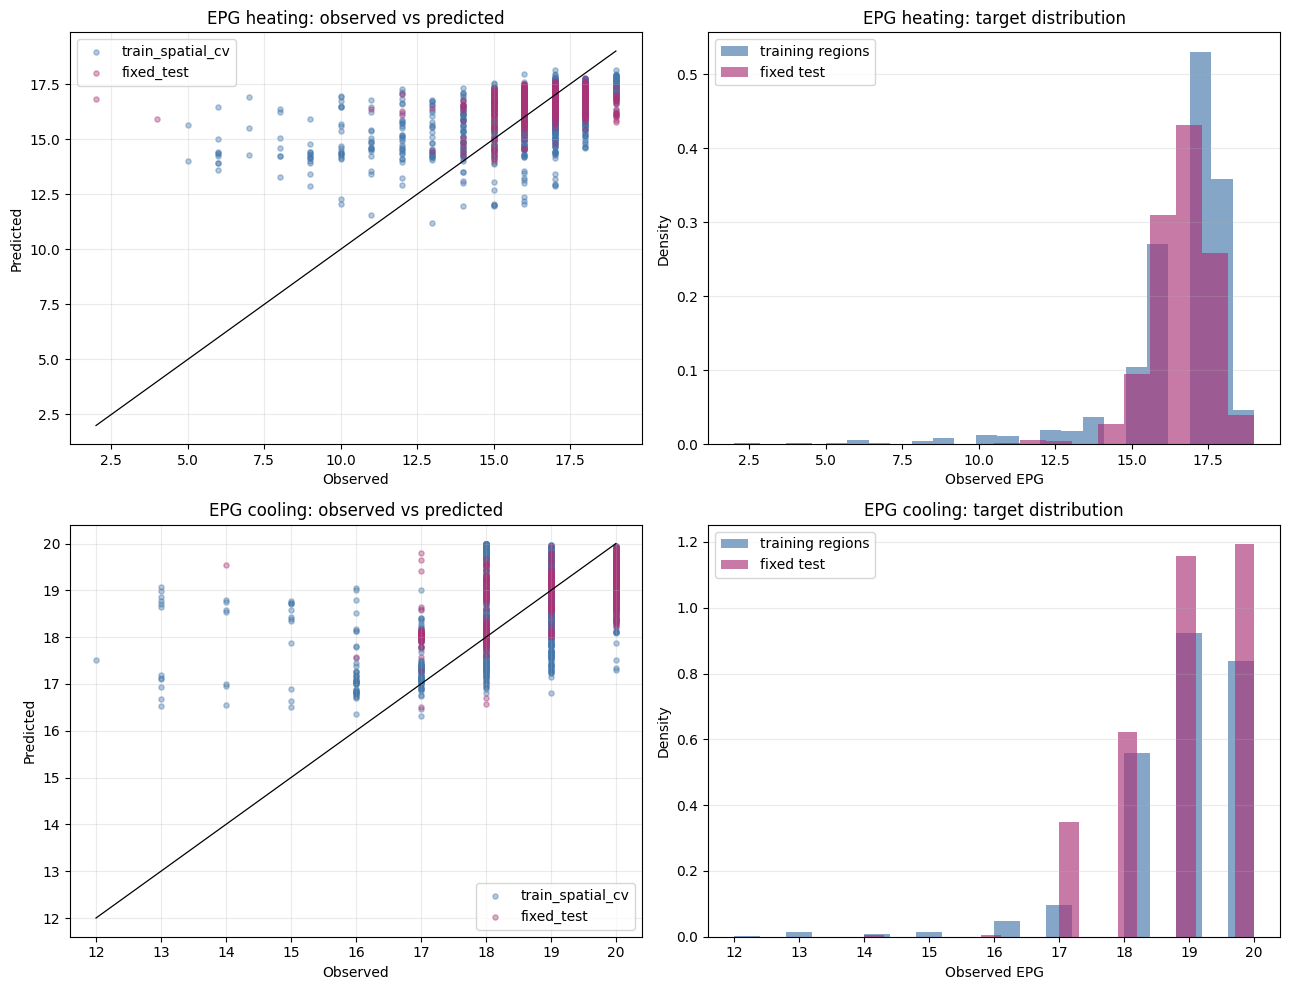

observed                             predicted  \
                                  min       mean   max       std        min   
target      prediction_role                                                   
EPG cooling fixed_test           14.0  18.947644  20.0  1.010806  16.516000   
            train_in_sample      12.0  18.908618  20.0  1.114680  13.750000   
            train_spatial_cv     12.0  18.908618  20.0  1.114680  16.310000   
EPG heating fixed_test            2.0  16.694590  19.0  1.410223  14.013609   
            train_in_sample       5.0  16.536596  19.0  1.864583  10.624862   
            train_spatial_cv      5.0  16.536596  19.0  1.864583  11.196820   

                                                              
                                   mean        max       std  
target      prediction_role                                   
EPG cooling fixed_test        18.858063  19.952000  0.565657  
            train_in_sample   18.905470  19.996000  0.978175  
            train_spatial_cv  18.828514  19.994000  0.722196  
EPG heating fixed_test        16.682876  17.789024  0.609668  
            train_in_sample   16.534731  18.491449  1.199555  
            train_spatial_cv  16.465438  18.160836  0.940055

,target,prediction_role,n,observed_mean,observed_std,share_epg_20,share_epg_19_or_20
0,EPG cooling,fixed_test,573,18.947644,1.010806,0.357766,0.705061
1,EPG cooling,train_in_sample,2309,18.908618,1.114680,0.335643,0.705500
2,EPG cooling,train_spatial_cv,2309,18.908618,1.114680,0.335643,0.705500
3,EPG heating,fixed_test,573,16.694590,1.410223,0.000000,0.033159
4,EPG heating,train_in_sample,2309,16.536596,1.864583,0.000000,0.032482
5,EPG heating,train_spatial_cv,2309,16.536596,1.864583,0.000000,0.032482


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for row, target in enumerate(EPG_TARGETS):
    ax = axes[row, 0]
    for role, color in [("train_spatial_cv", "#4477AA"), ("fixed_test", "#AA3377")]:
        part = epg_predictions.query("target == @target and prediction_role == @role")
        ax.scatter(part["observed"], part["predicted"], s=14, alpha=0.4, label=role, color=color)
    lo = epg_predictions.loc[epg_predictions["target"].eq(target), ["observed", "predicted"]].min().min()
    hi = epg_predictions.loc[epg_predictions["target"].eq(target), ["observed", "predicted"]].max().max()
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=0.9)
    ax.set_title(f"{target}: observed vs predicted")
    ax.set_xlabel("Observed")
    ax.set_ylabel("Predicted")
    ax.grid(alpha=0.25)
    ax.legend()

    ax = axes[row, 1]
    train_vals = epg_predictions.query("target == @target and prediction_role == 'train_spatial_cv'")["observed"]
    test_vals = epg_predictions.query("target == @target and prediction_role == 'fixed_test'")["observed"]
    ax.hist(train_vals, bins=20, alpha=0.65, density=True, label="training regions", color="#4477AA")
    ax.hist(test_vals, bins=20, alpha=0.65, density=True, label="fixed test", color="#AA3377")
    ax.set_title(f"{target}: target distribution")
    ax.set_xlabel("Observed EPG")
    ax.set_ylabel("Density")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
plt.tight_layout()
plt.show()

range_summary = epg_predictions.groupby(["target", "prediction_role"])[["observed", "predicted"]].agg(["min", "mean", "max", "std"])
display(range_summary)

epg_observed_distribution = (
    epg_predictions.groupby(["target", "prediction_role"], observed=True)
    .agg(
        n=("observed", "size"),
        observed_mean=("observed", "mean"),
        observed_std=("observed", "std"),
        share_epg_20=("observed", lambda values: values.eq(20).mean()),
        share_epg_19_or_20=("observed", lambda values: values.ge(19).mean()),
    )
    .reset_index()
)
display(epg_observed_distribution)

## Region-Level Errors

Region means expose systematic NUTS3 biases that parish-level scatter plots can hide. Negative mean residuals are overprediction; positive mean residuals are underprediction.

,target,prediction_role,NUTS3,n,observed_mean,predicted_mean,residual_mean,mae,rmse
1,EPG cooling,fixed_test,PT16J,266.0,19.575188,19.192970,0.382218,0.855496,0.984745
2,EPG cooling,fixed_test,PT185,68.0,17.441176,18.006088,-0.564912,0.858029,0.943830
3,EPG cooling,fixed_test,PT187,69.0,17.855072,17.996870,-0.141797,0.280696,0.470857
0,EPG cooling,fixed_test,PT112,170.0,19.011765,19.024365,-0.012600,0.164176,0.224630
11,EPG cooling,train_spatial_cv,PT150,67.0,15.477612,17.601313,-2.123701,2.349134,2.971348
9,EPG cooling,train_spatial_cv,PT11D,217.0,18.290323,19.634820,-1.344498,1.360719,1.456417
21,EPG cooling,train_spatial_cv,PT184,62.0,18.387097,17.536742,0.850355,0.852677,0.990658
16,EPG cooling,train_spatial_cv,PT16G,156.0,19.929487,19.121756,0.807731,0.826423,0.922733
10,EPG cooling,train_spatial_cv,PT11E,195.0,19.651282,19.048533,0.602749,0.773662,0.885495
8,EPG cooling,train_spatial_cv,PT11C,177.0,19.745763,18.990203,0.755559,0.759220,0.869117


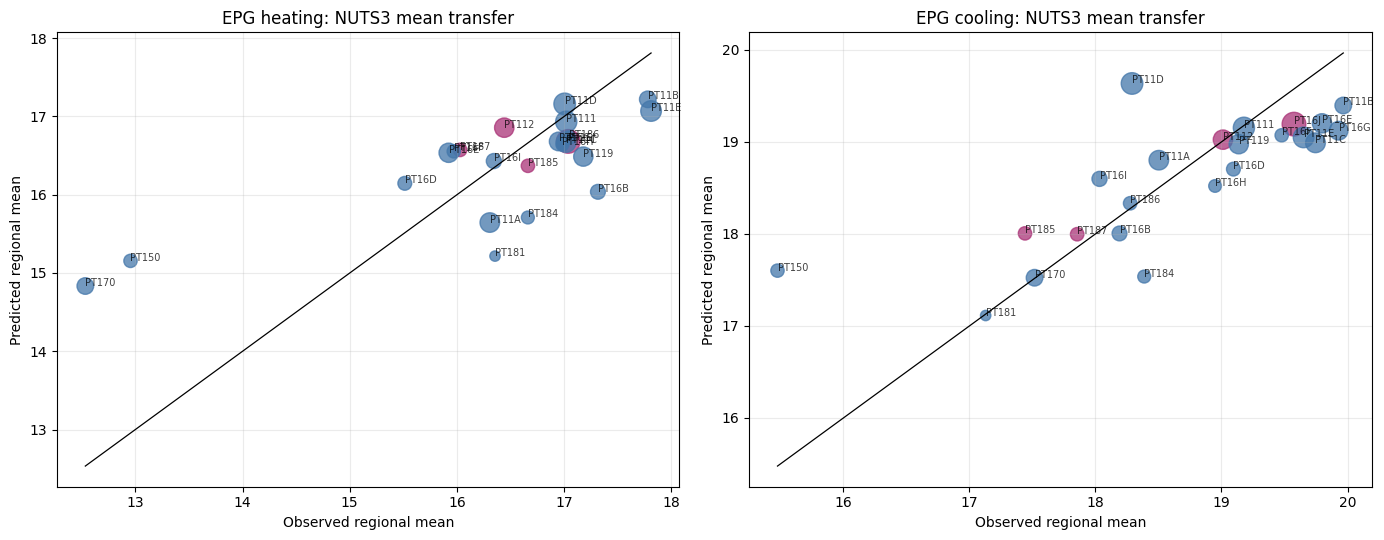

In [6]:
def regional_metrics(df: pd.DataFrame) -> pd.Series:
    return pd.Series({
        "n": len(df),
        "observed_mean": df["observed"].mean(),
        "predicted_mean": df["predicted"].mean(),
        "residual_mean": df["residual"].mean(),
        "mae": df["residual"].abs().mean(),
        "rmse": rf_utils.rmse(df["observed"], df["predicted"]),
    })

region_summary = (
    epg_predictions[epg_predictions["prediction_role"].isin(["train_spatial_cv", "fixed_test"])]
    .groupby(["target", "prediction_role", "NUTS3"], observed=True)
    .apply(regional_metrics, include_groups=False)
    .reset_index()
)
display(region_summary.sort_values(["target", "prediction_role", "rmse"], ascending=[True, True, False]).head(30))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, target in zip(axes, EPG_TARGETS):
    part = region_summary[region_summary["target"].eq(target)].copy()
    colors = part["prediction_role"].map({"train_spatial_cv": "#4477AA", "fixed_test": "#AA3377"})
    ax.scatter(part["observed_mean"], part["predicted_mean"], s=25 + part["n"], alpha=0.75, c=colors)
    lo = part[["observed_mean", "predicted_mean"]].min().min()
    hi = part[["observed_mean", "predicted_mean"]].max().max()
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=0.9)
    for row in part.itertuples(index=False):
        ax.annotate(row.NUTS3, (row.observed_mean, row.predicted_mean), fontsize=7, alpha=0.75)
    ax.set_title(f"{target}: NUTS3 mean transfer")
    ax.set_xlabel("Observed regional mean")
    ax.set_ylabel("Predicted regional mean")
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Residual Maps

The maps outline municipality boundaries in black only for the split being mapped. Maps that contain overseas residuals use the mainland-plus-insets layout. Mainland-only maps use a single mainland extent.

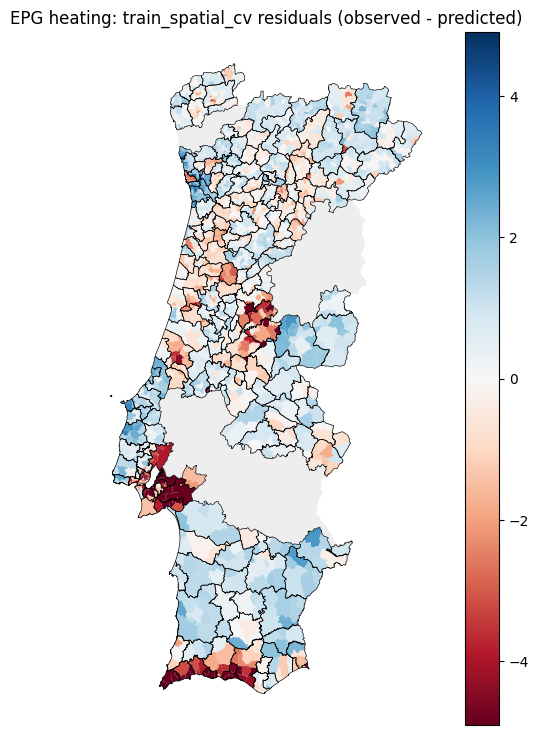

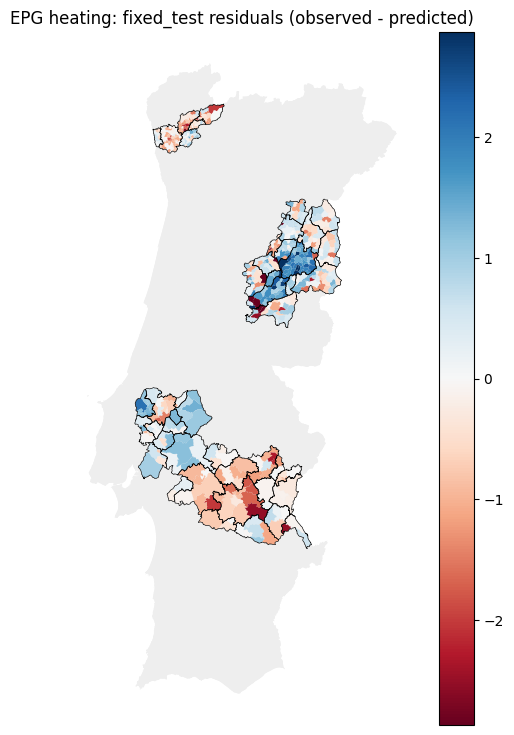

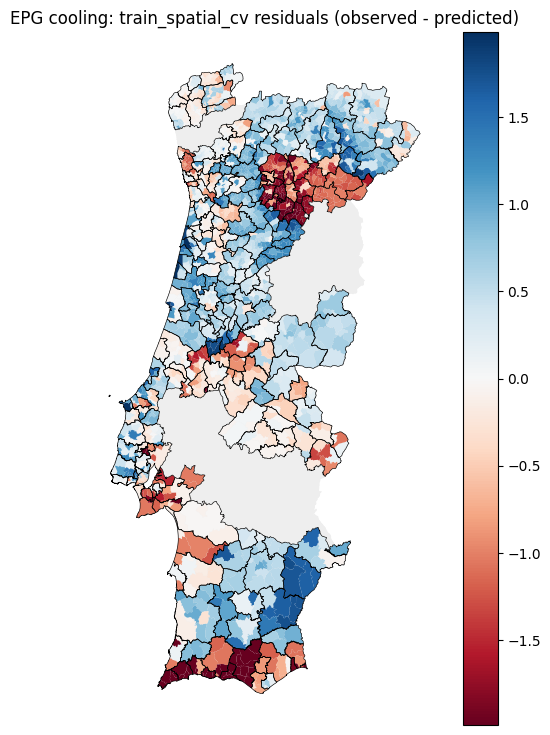

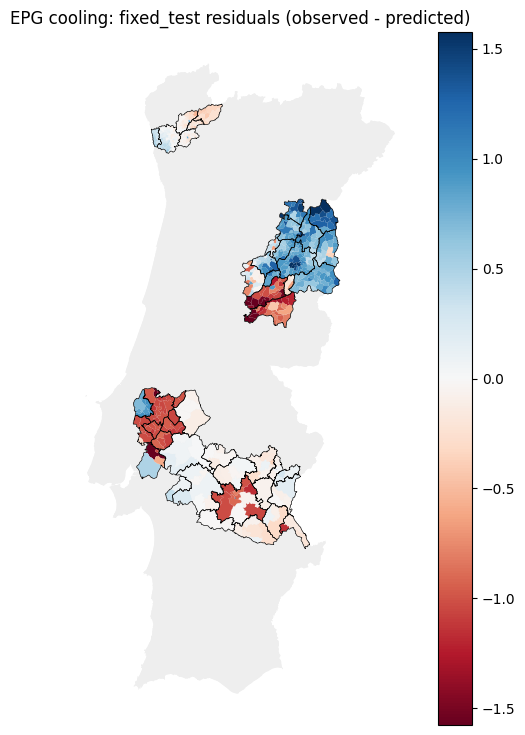

In [7]:
parishes = gpd.read_file(PARISH_GEOMETRY_GEOJSON)[["dicofre", "geometry"]].copy()
parishes["ID_norm"] = rf_utils.normalize_id(parishes["dicofre"])
nuts3_mapping = rf_utils.load_nuts3_mapping(repo_data_path(PATHS, "freguesias_to_NUTS3.csv"))
parishes = parishes.merge(nuts3_mapping, on="ID_norm", how="left")
parishes["municipality_id"] = parishes["ID_norm"].str[:4]

def add_bounds(ax, gdf):
    minx, miny, maxx, maxy = gdf.total_bounds
    padx = (maxx - minx) * 0.05 if maxx > minx else 1
    pady = (maxy - miny) * 0.05 if maxy > miny else 1
    ax.set_xlim(minx - padx, maxx + padx)
    ax.set_ylim(miny - pady, maxy + pady)
    ax.set_xticks([])
    ax.set_yticks([])

def residual_map(target: str, role: str):
    residuals = epg_predictions.query("target == @target and prediction_role == @role")[["ID_norm", "residual"]]
    gdf = parishes.merge(residuals, on="ID_norm", how="left")
    mainland = gdf.loc[~gdf["NUTS3"].isin(OVERSEAS_NUTS3)].copy()
    azores = gdf.loc[gdf["NUTS3"].eq("PT200")].copy()
    madeira = gdf.loc[gdf["NUTS3"].eq("PT300")].copy()
    def split_municipality_boundaries(part):
        mapped = part.loc[part["residual"].notna()].copy()
        if mapped.empty:
            return None
        return mapped.dissolve(by="municipality_id").boundary

    municipality_boundaries = {
        "mainland": split_municipality_boundaries(mainland),
        "azores": split_municipality_boundaries(azores),
        "madeira": split_municipality_boundaries(madeira),
    }
    finite = gdf["residual"].dropna().abs()
    limit = max(float(finite.quantile(0.98)) if not finite.empty else 1.0, 0.1)
    norm = TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)
    has_overseas_residuals = gdf.loc[gdf["residual"].notna(), "NUTS3"].isin(OVERSEAS_NUTS3).any()
    use_insets = (not EXCLUDE_OVERSEAS_TERRITORIES) and has_overseas_residuals
    if use_insets:
        fig = plt.figure(figsize=(10, 10))
        ax_main = fig.add_axes([0.33, 0.05, 0.64, 0.90])
        ax_azores = fig.add_axes([0.05, 0.54, 0.25, 0.30], frameon=True)
        ax_madeira = fig.add_axes([0.05, 0.17, 0.25, 0.30], frameon=True)
        panels = [(ax_main, mainland, "mainland", True), (ax_azores, azores, "azores", False), (ax_madeira, madeira, "madeira", False)]
    else:
        fig, ax_main = plt.subplots(figsize=(7, 9))
        panels = [(ax_main, mainland, "mainland", True)]

    for ax, part, boundary_key, legend in panels:
        part.plot(ax=ax, color="#eeeeee", linewidth=0)
        part.plot(ax=ax, column="residual", cmap="RdBu", norm=norm, legend=legend, linewidth=0, missing_kwds={"color": "#eeeeee"})
        boundaries = municipality_boundaries[boundary_key]
        if boundaries is not None:
            boundaries.plot(ax=ax, color="black", linewidth=0.45, zorder=20)
        add_bounds(ax, part)
        ax.set_facecolor("white")
    ax_main.set_axis_off()
    ax_main.set_title(f"{target}: {role} residuals (observed - predicted)")
    if use_insets:
        ax_azores.set_title("Azores", fontsize=10)
        ax_madeira.set_title("Madeira", fontsize=10)
        for ax in [ax_azores, ax_madeira]:
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_color("black")
                spine.set_linewidth(1.0)
    plt.show()

for target in EPG_TARGETS:
    residual_map(target, "train_spatial_cv")
    residual_map(target, "fixed_test")

## Predictor and Residual Diagnostics

Impurity importance describes the final training-fit forest, not causality. Residual correlations below ask a different question: which allowed predictors still align with EPG errors under spatial transfer?

In [8]:
SAT_CSV, _, _ = rf_utils.choose_satellite_csv(PATHS, repo_data_path, path_value)
inputs = rf_utils.load_prediction_inputs(
    sat_csv=SAT_CSV,
    adm_csv=repo_data_path(PATHS, "all_used_adm_indicators.csv"),
    epvi_csv=path_value(PATHS, "epvi_csv"),
    adm_split_json=repo_data_path(PATHS, "adm_data_split.json"),
)
model_df, predictor_cols, _ = rf_utils.build_modeling_table(inputs)
model_df = rf_utils.attach_nuts3(model_df, nuts3_mapping)
if EXCLUDE_OVERSEAS_TERRITORIES:
    model_df = model_df.loc[~model_df["NUTS3"].isin(OVERSEAS_NUTS3)].copy()
    predictor_cols = [c for c in predictor_cols if model_df[c].nunique(dropna=True) > 1]

for target in EPG_TARGETS:
    print("\n", target)
    display(epg_importances[epg_importances["target"].eq(target)].nlargest(15, "impurity_importance"))

residual_feature_rows = []
for target in EPG_TARGETS:
    for role in ["train_spatial_cv", "fixed_test"]:
        part = epg_predictions.query("target == @target and prediction_role == @role")[["ID_norm", "residual"]]
        joined = part.merge(model_df[["ID_norm", *predictor_cols]], on="ID_norm", how="left")
        for feature in predictor_cols:
            corr = joined[["residual", feature]].corr(method="spearman").iloc[0, 1]
            residual_feature_rows.append({"target": target, "prediction_role": role, "feature": feature, "residual_spearman": corr})
residual_feature_corr = pd.DataFrame(residual_feature_rows)
residual_feature_corr["abs_residual_spearman"] = residual_feature_corr["residual_spearman"].abs()
display(
    residual_feature_corr.sort_values("abs_residual_spearman", ascending=False)
    .groupby(["target", "prediction_role"], as_index=False, observed=True)
    .head(12)
)


 EPG heating


,model_scope,target,feature,impurity_importance
0,mainland_only,EPG heating,extreme_cold,0.110281
1,mainland_only,EPG heating,hdd_18,0.082808
2,mainland_only,EPG heating,share_of_superior_edu,0.062757
3,mainland_only,EPG heating,av_built_up_density,0.057900
4,mainland_only,EPG heating,age_x_res_vol,0.048567
5,mainland_only,EPG heating,age_x_height,0.047013
6,mainland_only,EPG heating,pop_density,0.046001
7,mainland_only,EPG heating,av_h,0.042935
8,mainland_only,EPG heating,ntl,0.042253
9,mainland_only,EPG heating,av_1_over_h,0.036764



 EPG cooling


,model_scope,target,feature,impurity_importance
47,mainland_only,EPG cooling,hdd_18,0.185767
48,mainland_only,EPG cooling,extreme_cold,0.153658
49,mainland_only,EPG cooling,cdd_25,0.065477
50,mainland_only,EPG cooling,ntl,0.053044
51,mainland_only,EPG cooling,delta_oc_per_capita,0.046678
52,mainland_only,EPG cooling,extreme_heat,0.041248
53,mainland_only,EPG cooling,standard_delta_bc,0.037361
54,mainland_only,EPG cooling,standard_delta_oc,0.036084
55,mainland_only,EPG cooling,delta_pm_25,0.029127
56,mainland_only,EPG cooling,standard_delta_pm_25,0.026612


,target,prediction_role,feature,residual_spearman,abs_residual_spearman
183,EPG cooling,fixed_test,extreme_cold,-0.541556,0.541556
165,EPG cooling,fixed_test,energy_per_vol_per_capita,-0.423947,0.423947
156,EPG cooling,fixed_test,pop_density,-0.409115,0.409115
78,EPG heating,fixed_test,standard_delta_pm_25,-0.370675,0.370675
77,EPG heating,fixed_test,delta_pm_25,-0.365109,0.365109
144,EPG cooling,fixed_test,res_vol_per_capita,0.356921,0.356921
177,EPG cooling,fixed_test,delta_oc,-0.338133,0.338133
174,EPG cooling,fixed_test,delta_bc,-0.337475,0.337475
171,EPG cooling,fixed_test,delta_pm_25,-0.314575,0.314575
89,EPG heating,fixed_test,extreme_cold,-0.313678,0.313678


## Readout Checklist

- If EPG random forests do not beat the mean baselines in fixed test or spatial CV, stop narrowing RF hyperparameters.
- If NUTS3 regional means are badly shifted or compressed, compare target distributions and consider explicit spatial baselines or region-transfer framing.
- If residual maps show contiguous regional errors, treat that as remaining spatial structure not learned from allowed predictors.
- If basic administrative variables dominate the EPG residual correlations, separate satellite-only and basic-admin-only baselines before interpreting satellite predictability.
